# -------------------: Multimodal Colon Cancer Detection Model :---------------------

In [3]:
import pandas as pd
video_data = pd.read_excel(r"C:\Users\upadh\Downloads\colonVideosWithLabels.xlsx")
patho_data = pd.read_excel(r"C:\Users\upadh\Downloads\pathoImagesWithLabels.xlsx")
ihc_data = pd.read_excel(r"C:\Users\upadh\Downloads\ihcData.xlsx")

print(video_data.columns)
print(patho_data.columns)
print(ihc_data.columns)

Index(['ID', 'colon', 'patient', 'polyp', 'gender', 'age', 'location', 'type',
       'subtype', 'Ki-67(clone30-9)', 'BRAF(cloneV600E)',
       'PD-L1epithelium(clone SP142)', 'PD-L1lymphocyte(clone SP142)',
       'VEGF(clone SP125)', 'CD34(cloneQBend/10)', 'CD34(cloneQBend/10)skor',
       'p53(clonebp53-11)'],
      dtype='object')
Index(['ID', 'imageNames', 'patho', 'patient', 'polyp', 'location', 'type',
       'subtype', 'zooming', 'Ki-67(clone30-9)', 'BRAF(cloneV600E)',
       'PD-L1epithelium(clone SP142)', 'PD-L1lymphocyte(clone SP142)',
       'VEGF(clone SP125)', 'CD34(cloneQBend/10)', 'CD34(cloneQBend/10)skor',
       'p53(clonebp53-11)'],
      dtype='object')
Index(['ID', 'colon', 'patient', 'polyp', 'gender', 'age', 'location', 'type',
       'subtype', 'Ki-67(clone30-9)', 'BRAF(cloneV600E)',
       'PD-L1epithelium(clone SP142)', 'PD-L1lymphocyte(clone SP142)',
       'VEGF(clone SP125)', 'CD34(cloneQBend/10)', 'CD34(cloneQBend/10)skor',
       'p53(clonebp53-11)'],
   

In [4]:
print(video_data.shape)
print(patho_data.shape)
print(ihc_data.shape)

(133, 17)
(1903, 17)
(407, 17)


In [6]:
print(video_data["patient"].nunique())
print(patho_data["patient"].nunique())
print(ihc_data["patient"].nunique())

132
198
201


In [7]:
print(video_data["type"].value_counts())
print(patho_data["type"].value_counts())
print(ihc_data["type"].value_counts())

type
neoplastic       76
nonneoplastic    51
carcinom          6
Name: count, dtype: int64
type
neoplastic       940
nonneoplastic    519
normal           370
carcinom          74
Name: count, dtype: int64
type
neoplastic       194
nonneoplastic    115
normal            78
carcinom          16
Name: count, dtype: int64


In [8]:
video_patients = set(video_data["patient"].astype(str))
path_patients = set(patho_data["patient"].astype(str))
ihc_patients = set(ihc_data["patient"].astype(str))

common_patients = (
    video_patients &
    path_patients &
    ihc_patients
)

print("Common Patients:", len(common_patients))

video_only = len(video_patients - common_patients)
path_only = len(path_patients - common_patients)
ihc_only = len(ihc_patients - common_patients)

print("Video only:", video_only)
print("Pathology only:", path_only)
print("IHC only:", ihc_only)

Common Patients: 130
Video only: 2
Pathology only: 68
IHC only: 72


In [10]:
video_patients = set(video_data["patient"].astype(str))
path_patients = set(patho_data["patient"].astype(str))
ihc_patients = set(ihc_data["patient"].astype(str))

common_patients = (
    video_patients &
    path_patients &
    ihc_patients
)

aligned_video = video_data[
    video_data["patient"].astype(str).isin(common_patients)
]

print(aligned_video["type"].value_counts())

type
neoplastic       76
nonneoplastic    50
carcinom          5
Name: count, dtype: int64


# Notebook 1 : Data Loading, EDA & Dataset Preparation

# 1. Import Libraries : 

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Define Dataset Paths : 

In [2]:
VIDEO_XLSX = r"C:\Users\upadh\Downloads\colonVideosWithLabels.xlsx"
PATHO_XLSX = r"C:\Users\upadh\Downloads\pathoImagesWithLabels.xlsx"
IHC_XLSX = r"C:\Users\upadh\Downloads\ihcData.xlsx"

# 3. Load Datasets : 

In [3]:
video_df = pd.read_excel(VIDEO_XLSX)
pathology_df = pd.read_excel(PATHO_XLSX)
ihc_df = pd.read_excel(IHC_XLSX)

print("Video Shape : ", video_df.shape)
print("Pathology Shape : ", pathology_df.shape)
print("IHC Shape : ", ihc_df.shape)

Video Shape :  (133, 17)
Pathology Shape :  (1903, 17)
IHC Shape :  (407, 17)


# 4. Display First Few Rows : 

In [4]:
print("VIDEO DATA")
display(video_df.head())

print("\nPATHOLOGY DATA")
display(pathology_df.head())

print("\nIHC DATA")
display(ihc_df.head())

VIDEO DATA


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11)
0,58,colon,patient58,polyp1,M,42.0,rectum,nonneoplastic,hyperplastic,15.0,strong,weak,weak,50.0,1.0,32.0,5.0
1,85,colon,patient85,polyp1,M,83.0,sigmoid,nonneoplastic,hyperplastic,30.0,strong,negative,weak,40.0,1.0,22.0,15.0
2,92,colon,patient92,polyp1,M,61.0,rectum,nonneoplastic,hyperplastic,30.0,strong,negative,weak,10.0,2.0,70.0,10.0
3,109,colon,patient109,polyp1,M,45.0,sigmoid,nonneoplastic,hyperplastic,20.0,strong,negative,weak,40.0,3.0,76.0,10.0
4,108,colon,patient108,polyp1,F,50.0,sigmoid,neoplastic,tubular,40.0,negative,negative,strong,90.0,2.0,70.0,15.0



PATHOLOGY DATA


,ID,imageNames,patho,patient,polyp,location,type,subtype,zooming,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11)
0,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX5,10.0,negative,negative,weak,10.0,68.0,2.0,1.0
1,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,"slideX2,5",10.0,negative,negative,weak,10.0,68.0,2.0,1.0
2,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX20,10.0,negative,negative,weak,10.0,68.0,2.0,1.0
3,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX10,10.0,negative,negative,weak,10.0,68.0,2.0,1.0
4,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX10,15.0,strong,negative,weak,80.0,67.0,2.0,15.0



IHC DATA


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11)
0,1,colon,patient1,polyp1,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,20.0,47.0,2.0,15.0
1,1,colon,patient1,polyp2,M,53,descending,nonneoplastic,hyperplastic,40.0,negative,negative,negative,30.0,39.0,2.0,10.0
2,1,colon,patient1,polyp3,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,50.0,50.0,3.0,20.0
3,2,colon,patient2,polyp1,M,49,ascending,nonneoplastic,hyperplastic,50.0,negative,negative,weak,40.0,63.0,3.0,5.0
4,2,colon,patient2,polyp2,M,49,descending,neoplastic,villous,60.0,negative,negative,weak,70.0,57.0,2.0,25.0


# 5. Dataset Information : 

In [5]:
print("="*60)
print("VIDEO INFO")
print("="*60)

video_df.info()

print("\n")

print("="*60)
print("PATHOLOGY INFO")
print("="*60)

pathology_df.info()

print("\n")

print("="*60)
print("IHC INFO")
print("="*60)

ihc_df.info()

VIDEO INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            133 non-null    int64  
 1   colon                         133 non-null    object 
 2   patient                       133 non-null    object 
 3   polyp                         133 non-null    object 
 4   gender                        133 non-null    object 
 5   age                           128 non-null    float64
 6   location                      133 non-null    object 
 7   type                          133 non-null    object 
 8   subtype                       133 non-null    object 
 9   Ki-67(clone30-9)              128 non-null    float64
 10  BRAF(cloneV600E)              129 non-null    object 
 11  PD-L1epithelium(clone SP142)  129 non-null    object 
 12  PD-L1lymphocyte(clone SP142)  129 non-null    object 

# 6. Missing Values : 

In [6]:
print("VIDEO MISSING VALUES")
display(video_df.isnull().sum())

print("\nPATHOLOGY MISSING VALUES")
display(pathology_df.isnull().sum())

print("\nIHC MISSING VALUES")
display(ihc_df.isnull().sum())

VIDEO MISSING VALUES


ID                              0
colon                           0
patient                         0
polyp                           0
gender                          0
age                             5
location                        0
type                            0
subtype                         0
Ki-67(clone30-9)                5
BRAF(cloneV600E)                4
PD-L1epithelium(clone SP142)    4
PD-L1lymphocyte(clone SP142)    4
VEGF(clone SP125)               4
CD34(cloneQBend/10)             4
CD34(cloneQBend/10)skor         4
p53(clonebp53-11)               4
dtype: int64


PATHOLOGY MISSING VALUES


ID                               0
imageNames                       0
patho                            0
patient                          0
polyp                            0
location                         0
type                             0
subtype                          0
zooming                          0
Ki-67(clone30-9)                78
BRAF(cloneV600E)                68
PD-L1epithelium(clone SP142)    68
PD-L1lymphocyte(clone SP142)    68
VEGF(clone SP125)               68
CD34(cloneQBend/10)             68
CD34(cloneQBend/10)skor         68
p53(clonebp53-11)               68
dtype: int64


IHC MISSING VALUES


ID                               0
colon                            1
patient                          9
polyp                            8
gender                           0
age                              0
location                         0
type                             4
subtype                          4
Ki-67(clone30-9)                15
BRAF(cloneV600E)                13
PD-L1epithelium(clone SP142)    13
PD-L1lymphocyte(clone SP142)    13
VEGF(clone SP125)               13
CD34(cloneQBend/10)             13
CD34(cloneQBend/10)skor         13
p53(clonebp53-11)               13
dtype: int64

# 7. Duplicate Rows : 

In [7]:
print("Video Duplicates : ", video_df.duplicated().sum())
print("Pathology Duplicates : ", pathology_df.duplicated().sum())
print("IHC Duplicates : ", ihc_df.duplicated().sum())

Video Duplicates :  0
Pathology Duplicates :  0
IHC Duplicates :  0


# 8. Unique Patients : 

In [8]:
print("Unique Video Patients : ", video_df["patient"].nunique())
print("Unique Pathology Patients : ", pathology_df["patient"].nunique())
print("Unique IHC Patients : ", ihc_df["patient"].nunique())

Unique Video Patients :  132
Unique Pathology Patients :  198
Unique IHC Patients :  201


# 9. Common Patient Analysis : 

In [9]:
video_patients = set(video_df["patient"].astype(str))
path_patients = set(pathology_df["patient"].astype(str))
ihc_patients = set(ihc_df["patient"].astype(str))

common_patients = (video_patients & path_patients & ihc_patients)

print("Common Patients : ", len(common_patients))
print("Video Only : ", len(video_patients-common_patients))
print("Pathology Only : ", len(path_patients-common_patients))
print("IHC Only : ", len(ihc_patients-common_patients))

Common Patients :  130
Video Only :  2
Pathology Only :  68
IHC Only :  72


# 10. Class Distribution : 

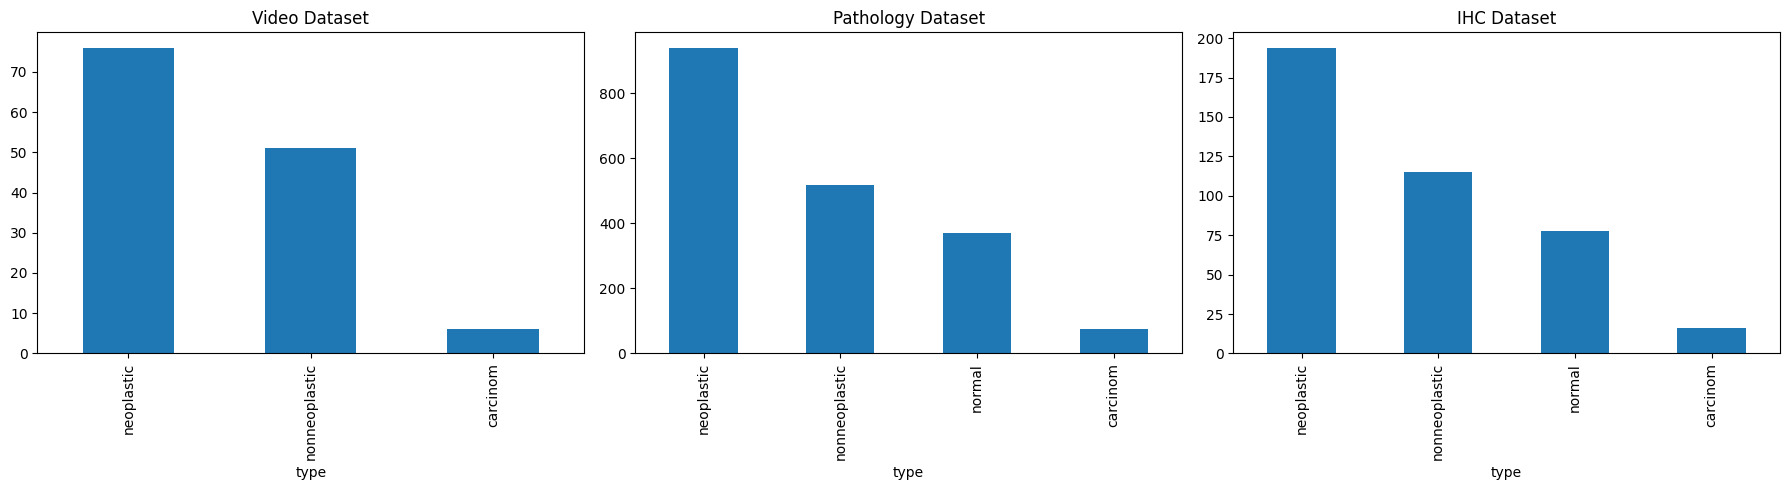

In [10]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

video_df["type"].value_counts().plot(kind="bar", ax=axes[0], title="Video Dataset")
pathology_df["type"].value_counts().plot(kind="bar", ax=axes[1], title="Pathology Dataset")
ihc_df["type"].value_counts().plot(kind="bar", ax=axes[2], title="IHC Dataset")

plt.tight_layout()
plt.show()

# 11. Standardize Class Names : 

In [11]:
def clean_type(x) :
    if pd.isna(x) :
        return np.nan

    x = str(x).strip().lower()
    mapping = {
        "nonneoplastic": "nonneoplastic",
        "neoplastic": "neoplastic",
        "normal": "normal",
        "carcinom": "carcinom"
    }
    return mapping.get(x, np.nan)

video_df["type"] = video_df["type"].apply(clean_type)
pathology_df["type"] = pathology_df["type"].apply(clean_type)
ihc_df["type"] = ihc_df["type"].apply(clean_type)

In [12]:
print("Before Cleaning")
print("Video:", len(video_df))
print("Pathology:", len(pathology_df))
print("IHC:", len(ihc_df))

video_df = video_df.dropna(subset=["type"]).reset_index(drop=True)

pathology_df = pathology_df.dropna(subset=["type"]).reset_index(drop=True)

ihc_df = ihc_df.dropna(subset=["type"]).reset_index(drop=True)

print("\nAfter Cleaning")
print("Video:", len(video_df))
print("Pathology:", len(pathology_df))
print("IHC:", len(ihc_df))

Before Cleaning
Video: 133
Pathology: 1903
IHC: 407

After Cleaning
Video: 133
Pathology: 1903
IHC: 403


# 12. Verify Classes : 

In [13]:
print(sorted(video_df["type"].unique()))
print(sorted(pathology_df["type"].unique()))
print(sorted(ihc_df["type"].unique()))

['carcinom', 'neoplastic', 'nonneoplastic']
['carcinom', 'neoplastic', 'nonneoplastic', 'normal']
['carcinom', 'neoplastic', 'nonneoplastic', 'normal']


In [14]:
ihc_df["type"].value_counts(dropna=False)

type
neoplastic       194
nonneoplastic    115
normal            78
carcinom          16
Name: count, dtype: int64

# 13. Label Encoding : 

In [15]:
all_labels = pd.concat([
    video_df["type"],
    pathology_df["type"],
    ihc_df["type"]
])

label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

print("Classes:")
print(label_encoder.classes_)

Classes:
['carcinom' 'neoplastic' 'nonneoplastic' 'normal']


# 14. Create Label IDs : 

In [16]:
video_df["LabelID"] = label_encoder.transform(video_df["type"])
pathology_df["LabelID"] = label_encoder.transform(pathology_df["type"])
ihc_df["LabelID"] = label_encoder.transform(ihc_df["type"])

# 15. Verify Label Mapping : 

In [17]:
label_mapping = {cls : idx
    for idx, cls in enumerate(label_encoder.classes_)
}

print(label_mapping)

{'carcinom': 0, 'neoplastic': 1, 'nonneoplastic': 2, 'normal': 3}


# 16. Check Encoded Distribution : 

In [18]:
print("VIDEO")
print(video_df["LabelID"].value_counts().sort_index())

print("\nPATHOLOGY")
print(pathology_df["LabelID"].value_counts().sort_index())

print("\nIHC")
print(ihc_df["LabelID"].value_counts().sort_index())

VIDEO
LabelID
0     6
1    76
2    51
Name: count, dtype: int64

PATHOLOGY
LabelID
0     74
1    940
2    519
3    370
Name: count, dtype: int64

IHC
LabelID
0     16
1    194
2    115
3     78
Name: count, dtype: int64


# 17. Save Label Encoder : 

In [19]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    label_encoder,
    "artifacts/label_encoder.pkl"
)

print("Label Encoder Saved")

Label Encoder Saved


# 18. Save Label Mapping CSV : 

In [20]:
mapping_df = pd.DataFrame({
    "ClassName" : label_encoder.classes_,
    "LabelID" : range(len(label_encoder.classes_))
})
mapping_df.to_csv(
    "artifacts/label_mapping.csv",
    index=False
)
mapping_df

,ClassName,LabelID
0,carcinom,0
1,neoplastic,1
2,nonneoplastic,2
3,normal,3


# 19. Save Cleaned Data : 

In [21]:
video_df.to_csv("artifacts/video_clean.csv", index=False)
pathology_df.to_csv("artifacts/pathology_clean.csv", index=False)
ihc_df.to_csv("artifacts/ihc_clean.csv", index=False)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


# 20. Final Dataset Summary : 

In [22]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Video Dataset Shape      : {video_df.shape}")
print(f"Pathology Dataset Shape  : {pathology_df.shape}")
print(f"IHC Dataset Shape        : {ihc_df.shape}")

print("\nNumber of Classes:")
print(len(label_encoder.classes_))

print("\nClass Names:")
print(label_encoder.classes_)

print("\nUnique Video Patients:")
print(video_df['patient'].nunique())

print("\nUnique Pathology Patients:")
print(pathology_df['patient'].nunique())

print("\nUnique IHC Patients:")
print(ihc_df['patient'].nunique())

DATASET SUMMARY
Video Dataset Shape      : (133, 18)
Pathology Dataset Shape  : (1903, 18)
IHC Dataset Shape        : (403, 18)

Number of Classes:
4

Class Names:
['carcinom' 'neoplastic' 'nonneoplastic' 'normal']

Unique Video Patients:
132

Unique Pathology Patients:
198

Unique IHC Patients:
201


# Notebook 2 : Video Frame Extraction (1 FPS)

# 1. Import Libraries : 

In [23]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

# 2. Load Cleaned Video Dataset : 

In [24]:
video_df = pd.read_csv("artifacts/video_clean.csv")
print(video_df.shape)
video_df.head()

(133, 18)


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,58,colon,patient58,polyp1,M,42.0,rectum,nonneoplastic,hyperplastic,15.0,strong,weak,weak,50.0,1.0,32.0,5.0,2
1,85,colon,patient85,polyp1,M,83.0,sigmoid,nonneoplastic,hyperplastic,30.0,strong,negative,weak,40.0,1.0,22.0,15.0,2
2,92,colon,patient92,polyp1,M,61.0,rectum,nonneoplastic,hyperplastic,30.0,strong,negative,weak,10.0,2.0,70.0,10.0,2
3,109,colon,patient109,polyp1,M,45.0,sigmoid,nonneoplastic,hyperplastic,20.0,strong,negative,weak,40.0,3.0,76.0,10.0,2
4,108,colon,patient108,polyp1,F,50.0,sigmoid,neoplastic,tubular,40.0,negative,negative,strong,90.0,2.0,70.0,15.0,1


# 3. Define Video Folder Path : 

In [25]:
VIDEO_FOLDER = r"C:\Users\upadh\Downloads\colonVideosWithLabels"
OUTPUT_FOLDER = r"processed_data\video_frames"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Output Folder Ready")

Output Folder Ready


# 4. Inspect Video Filename Column : 

In [26]:
import os

video_files = [
    f for f in os.listdir(VIDEO_FOLDER)
    if f.endswith(".avi")
]

print("Total AVI Files :", len(video_files))
video_files[:5]

Total AVI Files : 132


['colon-patient10-polyp1-M-83-rectum-neoplastic-tubulovillous-70-negative-negative-weak-50-2-58-50.avi',
 'colon-patient101-polyp1-F-63-sigmoid-neoplastic-tubular-25-negative-negative-weak-20-1-30-10.avi',
 'colon-patient103-polyp1-F-65-rectum-nonneoplastic-hyperplastic-15-kuvvetli-negative-weak-90-2-49-10.avi',
 'colon-patient105-polyp1-M-65-rectum-neoplastic-tubular-40-negative-weak-weak-0-1-39-50.avi',
 'colon-patient106-polyp1-M-67-rectum-neoplastic-tubular-30-negative-weak-weak-80-2-56-25.avi']

# 5. Create Patient To Video Mapping : 

In [27]:
import re

patient_video_map = {}

for file in video_files :
    match = re.search(r"patient(\d+)", file)

    if match :
        patient_id = f"patient{match.group(1)}"
        patient_video_map[patient_id] = file

print("Mapped Patients : ", len(patient_video_map))
list(patient_video_map.items())[:5]

Mapped Patients :  131


[('patient10',
  'colon-patient10-polyp1-M-83-rectum-neoplastic-tubulovillous-70-negative-negative-weak-50-2-58-50.avi'),
 ('patient101',
  'colon-patient101-polyp1-F-63-sigmoid-neoplastic-tubular-25-negative-negative-weak-20-1-30-10.avi'),
 ('patient103',
  'colon-patient103-polyp1-F-65-rectum-nonneoplastic-hyperplastic-15-kuvvetli-negative-weak-90-2-49-10.avi'),
 ('patient105',
  'colon-patient105-polyp1-M-65-rectum-neoplastic-tubular-40-negative-weak-weak-0-1-39-50.avi'),
 ('patient106',
  'colon-patient106-polyp1-M-67-rectum-neoplastic-tubular-30-negative-weak-weak-80-2-56-25.avi')]

# 6. Find Missing Patient : 

In [28]:
matched = 0
missing = []

for patient in video_df["patient"] :
    if patient in patient_video_map :
        matched += 1
    else :
        missing.append(patient)

print("Matched : ", matched)
print("Missing : ", len(missing))
print(missing[:10])

Matched :  132
Missing :  1
['patient184']


# 7. Extract Frames Function : 

In [29]:
def extract_frames_1fps(video_path, output_dir, resize=(224, 224)) :
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0 :
        fps = 25

    frame_interval = int(fps)
    frame_count = 0
    saved_count = 0

    while True :
        success, frame = cap.read()

        if not success :
            break

        if frame_count % frame_interval == 0 :
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, resize)
            save_path = os.path.join(output_dir, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(
                save_path,
                cv2.cvtColor(
                    frame,
                    cv2.COLOR_RGB2BGR
                )
            )
            saved_count += 1

        frame_count += 1

    cap.release()
    return saved_count

# 8. Extract Frames From All Videos : 

In [30]:
frame_stats = []

for _, row in tqdm(video_df.iterrows(), total=len(video_df)) :
    patient = str(row["patient"])

    if patient not in patient_video_map :
        print(f"Skipping {patient}")
        continue

    video_file = patient_video_map[patient]
    video_path = os.path.join(VIDEO_FOLDER, video_file)
    patient_folder = os.path.join(OUTPUT_FOLDER, patient)
    os.makedirs(patient_folder, exist_ok=True)
    num_frames = extract_frames_1fps(video_path, patient_folder)
    frame_stats.append(
        {
            "patient" : patient,
            "video" : video_file,
            "frames" : num_frames
        }
    )

print("Frame Extraction Complete")

 92%|█████████████████████████████████████████████████████████████████████████▍      | 122/133 [13:32<02:24, 13.11s/it]

Skipping patient184


100%|████████████████████████████████████████████████████████████████████████████████| 133/133 [15:47<00:00,  7.12s/it]

Frame Extraction Complete


# 9. Create Statistics Dataframe : 

In [31]:
frame_stats_df = pd.DataFrame(frame_stats)
print(frame_stats_df.shape)
frame_stats_df.head()

(132, 3)


,patient,video,frames
0,patient58,colon-patient58-polyp1-M-42-rectum-nonneoplast...,19
1,patient85,colon-patient85-polyp1-M-83-sigmoid-nonneoplas...,14
2,patient92,colon-patient92-polyp1-M-61-rectum-nonneoplast...,20
3,patient109,colon-patient109-polyp1-M-45-sigmoid-nonneopla...,22
4,patient108,colon-patient108-polyp1-F-50-sigmoid-neoplasti...,38


# 10. Save Statistics : 

In [32]:
os.makedirs("artifacts", exist_ok=True)
frame_stats_df.to_csv("artifacts/frame_statistics.csv", index=False)

print("Statistics Saved")

Statistics Saved


# 11. Frame Distribution : 

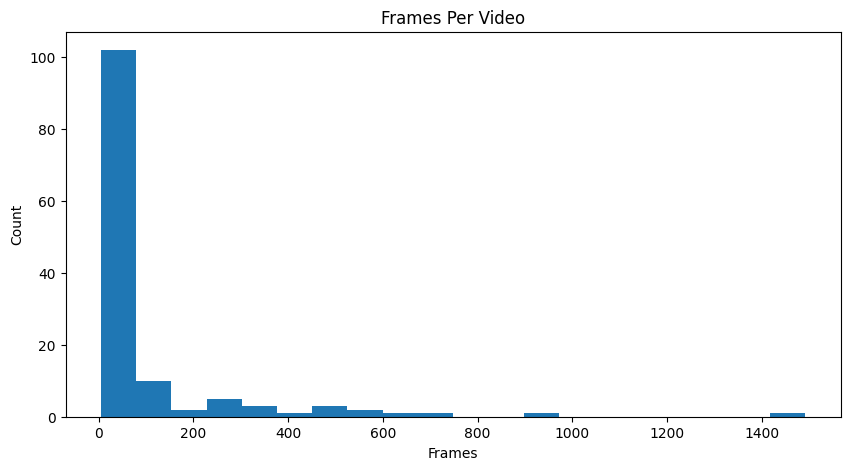

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(frame_stats_df["frames"], bins=20)
plt.title("Frames Per Video")
plt.xlabel("Frames")
plt.ylabel("Count")
plt.show()

# 12. Summary Statistics : 

In [34]:
frame_stats_df["frames"].describe()

count     132.000000
mean       95.696970
std       200.497585
min         5.000000
25%        12.750000
50%        19.000000
75%        53.750000
max      1492.000000
Name: frames, dtype: float64

# 13. Check Minimum Frames : 

In [35]:
print("Minimum Frames : ", frame_stats_df["frames"].min())
print("Maximum Frames : ", frame_stats_df["frames"].max())
print("Average Frames : ", frame_stats_df["frames"].mean())

Minimum Frames :  5
Maximum Frames :  1492
Average Frames :  95.6969696969697


# 14. Find Short Videos : 

In [36]:
short_videos = frame_stats_df[frame_stats_df["frames"] < 8]
print("Videos with <8 frames : ", len(short_videos))
short_videos.head()

Videos with <8 frames :  7


,patient,video,frames
27,patient25,colon-patient25-polyp1-M-64-ascending-neoplast...,6
69,patient99,colon-patient99-polyp1-M-47-descending-neoplas...,5
77,patient116,colon-patient116-polyp1-F-84-sigmoid-neoplasti...,5
85,patient127,colon-patient127-polyp1-F-77-rectum-nonneoplas...,6
89,patient134,colon-patient134-polyp1-M-66-descending-nonneo...,5


# 15. Save Valid Patients : 

In [37]:
MIN_FRAMES = 8
valid_patients = frame_stats_df[frame_stats_df["frames"] >= MIN_FRAMES]
valid_patients.to_csv("artifacts/valid_video_patients.csv", index=False)

print("Valid Patients : ", len(valid_patients))

Valid Patients :  125


# 16. Visual Inspection : 

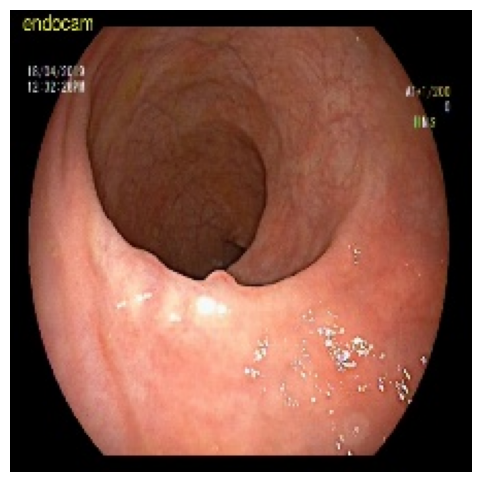

In [38]:
sample_patient = frame_stats_df.iloc[0]["patient"]
sample_folder = os.path.join(OUTPUT_FOLDER, sample_patient)
sample_image = sorted(os.listdir(sample_folder))[0]
img = cv2.imread(os.path.join(sample_folder, sample_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

# 17. Notebook Summary : 

In [39]:
print("="*60)
print("NOTEBOOK 2 COMPLETED")
print("="*60)

print("Processed Videos : ", len(frame_stats_df))
print("Valid Patients : ", len(valid_patients))
print("Average Frames : ", round(frame_stats_df["frames"].mean(), 2))

NOTEBOOK 2 COMPLETED
Processed Videos :  132
Valid Patients :  125
Average Frames :  95.7


# Notebook 3 : VideoMAE-S Feature Extraction

# 1. Install Dependencies : 

In [61]:
!pip install transformers timm accelerate -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Import Libraries : 

In [40]:
import os
import torch
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

from transformers import VideoMAEModel

# 3. Device Configeration : 

In [41]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


# 4. Load Valid Patients : 

In [42]:
valid_patients = pd.read_csv("artifacts/valid_video_patients.csv")
print(valid_patients.shape)
valid_patients.head()

(125, 3)


,patient,video,frames
0,patient58,colon-patient58-polyp1-M-42-rectum-nonneoplast...,19
1,patient85,colon-patient85-polyp1-M-83-sigmoid-nonneoplas...,14
2,patient92,colon-patient92-polyp1-M-61-rectum-nonneoplast...,20
3,patient109,colon-patient109-polyp1-M-45-sigmoid-nonneopla...,22
4,patient108,colon-patient108-polyp1-F-50-sigmoid-neoplasti...,38


# 5. Load Video MAE-S : 

In [43]:
model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
model.eval()
model.to(device)
print("VideoMAE Loaded")

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.v_bias       | UNEXPECTED |  | 
encoder_to_decoder.weight                                            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias       

VideoMAE Loaded


# 6. Define Frame Directory : 

In [44]:
FRAME_DIR = r"processed_data\video_frames"

# 7. Uniform Frame Sampling : 

In [45]:
def sample_frames(frame_paths, num_frames=16) :
    n = len(frame_paths)

    if n >= num_frames :
        idx = np.linspace(0, n-1, num_frames).astype(int)
        frame_paths = [frame_paths[i] for i in idx]

    else:

        while len(frame_paths) < num_frames:
            frame_paths.append(frame_paths[-1])

    return frame_paths

# 8. Frame Loader : 

In [46]:
def load_video_tensor(patient_folder, size=224) :
    frames = sorted([os.path.join(patient_folder, x)
        for x in os.listdir(
            patient_folder
        )
        if x.endswith(".jpg")
    ])
    frames = sample_frames(frames, num_frames=16)
    video = []

    for frame_path in frames :
        img = Image.open(frame_path).convert("RGB")
        img = img.resize((size,size))
        img = np.array(img)/255.0
        video.append(img)

    video = np.stack(video)
    video = torch.tensor(video, dtype=torch.float32)
    return video

# 9. Extract VideoMAE Features : 

In [47]:
video_features = []
patient_ids = []

# 10. Feature Extraction Loop : 

In [48]:
with torch.no_grad() :
    for patient in tqdm(valid_patients["patient"]) :
        patient_folder = os.path.join(FRAME_DIR, str(patient))
        video = load_video_tensor(patient_folder)
        video = (video.permute(0,3,1,2).unsqueeze(0).to(device))
        outputs = model(pixel_values=video)
        feature = (outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy())
        video_features.append(feature)
        patient_ids.append(patient)

100%|████████████████████████████████████████████████████████████████████████████████| 125/125 [00:54<00:00,  2.30it/s]


# 11. Convert To NumPy : 

In [49]:
video_features = np.array(video_features)
print(video_features.shape)

(125, 768)


# 12. Project To 512-D : 

In [50]:
import torch.nn as nn

projection = nn.Linear(768, 512)
with torch.no_grad() :
    projected_features = projection(torch.tensor(video_features, dtype=torch.float32))
    
video_features = (projected_features.numpy())

# 13. Verify Shape : 

In [51]:
print(video_features.shape)

(125, 512)


# 14. Save Features : 

In [52]:
os.makedirs("features", exist_ok=True)
np.save("features/video_features.npy", video_features)
np.save("features/video_patient_ids.npy", np.array(patient_ids))

print("Saved")

Saved


# 15. Feature Statistics : 

In [53]:
print(video_features.mean())
print(video_features.std())

0.010140632
0.2747043


# 16. Notebook Summary : 

In [54]:
print("="*60)
print("NOTEBOOK 3 COMPLETE")
print("="*60)

print("Patients : ", len(patient_ids))
print("Feature Shape : ", video_features.shape)

NOTEBOOK 3 COMPLETE
Patients :  125
Feature Shape :  (125, 512)


# Notebook 4 : Histopathology Image Preparation & Patient-wise Organization

# 1. Import Libraries : 

In [55]:
import os
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt

# 2. Load Cleaned Pathology Dataset : 

In [56]:
pathology_df = pd.read_csv("artifacts/pathology_clean.csv")
print(pathology_df.shape)
pathology_df.head()

(1903, 18)


,ID,imageNames,patho,patient,polyp,location,type,subtype,zooming,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX5,10.0,negative,negative,weak,10.0,68.0,2.0,1.0,3
1,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,"slideX2,5",10.0,negative,negative,weak,10.0,68.0,2.0,1.0,3
2,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX20,10.0,negative,negative,weak,10.0,68.0,2.0,1.0,3
3,100,patho-patient100-normal-sigmoid-normal-inflamm...,patho,patient100,normal,sigmoid,normal,inflammation,slideX10,10.0,negative,negative,weak,10.0,68.0,2.0,1.0,3
4,100,patho-patient100-polyp1-rectum-nonneoplastic-h...,patho,patient100,polyp1,rectum,nonneoplastic,hyperplastic,slideX10,15.0,strong,negative,weak,80.0,67.0,2.0,15.0,2


# 3. Basic Information : 

In [57]:
print("Unique Patients : ", pathology_df["patient"].nunique())
print("\nZoom Levels : ")
print(pathology_df["zooming"].value_counts())

Unique Patients :  198

Zoom Levels : 
zooming
slideX5        385
slideX2,5      385
slideX10       383
slideX20       379
slideX40       314
slideX20_1      10
slideX10_2       8
slideX20_2       8
slideX10_1       6
slideX5_2        4
slideX2,5_2      3
slideX5_3        2
slideX5_1        2
slideX10_3       2
slideX2,5_1      2
slideX5_4        2
slideX10_4       1
slideX40_1       1
slideX20_        1
slideX40_2       1
slideX5_5        1
slideX2,5_3      1
slideX2,5_4      1
slideX2,5_5      1
Name: count, dtype: int64


# 4. Define Pathology Root Folder : 

In [58]:
PATHO_ROOT = r"C:\Users\upadh\Downloads\histoImagesWithZoomingLabels"

# 5. Verify Image Counts In Each Folder : 

In [59]:
import os

for folder in os.listdir(PATHO_ROOT) :
    folder_path = os.path.join(PATHO_ROOT, folder)
    
    if os.path.isdir(folder_path) :
        print(folder, len(os.listdir(folder_path)))

10x 400
2,5x 393
20x 399
40x 316
5x 397


# 6. Inspect Image Name Format : 

In [60]:
pathology_df[["imageNames", "patient", "zooming"]].head(20)

,imageNames,patient,zooming
0,patho-patient100-normal-sigmoid-normal-inflamm...,patient100,slideX5
1,patho-patient100-normal-sigmoid-normal-inflamm...,patient100,"slideX2,5"
2,patho-patient100-normal-sigmoid-normal-inflamm...,patient100,slideX20
3,patho-patient100-normal-sigmoid-normal-inflamm...,patient100,slideX10
4,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX10
5,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX40
6,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX5
7,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,slideX20
8,patho-patient100-polyp1-rectum-nonneoplastic-h...,patient100,"slideX2,5"
9,patho-patient100-polyp2-sigmoid-neoplastic-tub...,patient100,"slideX2,5"


# 7. Inspect Actual Image Files from Each Magnification : 

In [61]:
import os

for folder in ["2,5x", "5x", "10x", "20x", "40x"] :
    folder_path = os.path.join(PATHO_ROOT, folder)
    files = os.listdir(folder_path)

    print("\n" + "="*50)
    print("Folder:", folder)
    print("Total Files:", len(files))
    print("Sample Files:")
    
    for f in files[:5] :
        print(f)


Folder: 2,5x
Total Files: 393
Sample Files:
patho-patient1-polyp2-descending-nonneoplastic-hyperplastic-slideX2,5.tiff
patho-patient1-polyp3-descending-nonneoplastic-hyperplastic-slideX2,5.tiff
patho-patient10-polyp1-rectum-neoplastic-tubulovillous-slideX2,5_1.tiff
patho-patient10-polyp1-rectum-neoplastic-tubulovillous-slideX2,5_2.tiff
patho-patient100-normal-sigmoid-normal-inflammation-slideX2,5.tiff

Folder: 5x
Total Files: 397
Sample Files:
.DS_Store
patho-patient1-polyp1-descending-nonneoplastic-hyperplastic-slideX5.tiff
patho-patient1-polyp2-descending-nonneoplastic-hyperplastic-slideX5.tiff
patho-patient1-polyp3-descending-nonneoplastic-hyperplastic-slideX5.tiff
patho-patient10-polyp1-rectum-neoplastic-tubulovillous-slideX5_1.tiff

Folder: 10x
Total Files: 400
Sample Files:
patho-patient1-polyp1-descending-nonneoplastic-hyperplastic-slideX10.tiff
patho-patient1-polyp2-descending-nonneoplastic-hyperplastic-slideX10.tiff
patho-patient1-polyp3-descending-nonneoplastic-hyperplastic-

# 8. Check Patient Statistics : 

In [62]:
patient_counts = (pathology_df.groupby("patient").size())
patient_counts.describe()

count    198.000000
mean       9.611111
std        6.852713
min        3.000000
25%        5.000000
50%        8.500000
75%       10.000000
max       63.000000
dtype: float64

# 9. Image Per Patient : 

In [63]:
print("Minimum Images per Patient : ", patient_counts.min())
print("Maximum Images per Patient : ", patient_counts.max())
print("Average Images per Patient : ", round(patient_counts.mean(),2))

Minimum Images per Patient :  3
Maximum Images per Patient :  63
Average Images per Patient :  9.61


# 10. Check 20X Coverage : 

In [64]:
zoom20_df = pathology_df[
    pathology_df["zooming"]
    .str.contains("slideX20",
                  na=False)
]

print("20x Images : ", len(zoom20_df))
print("20x Patients : ", zoom20_df["patient"].nunique())

20x Images :  398
20x Patients :  198


# 11. Normalize Zoom Labels : 

In [65]:
def normalize_zoom(z) :
    z = str(z)

    if "slideX2,5" in z :
        return "2.5x"

    elif "slideX5" in z :
        return "5x"

    elif "slideX10" in z :
        return "10x"

    elif "slideX20" in z :
        return "20x"

    elif "slideX40" in z :
        return "40x"

    return "unknown"


pathology_df["zoom_level"] = (pathology_df["zooming"].apply(normalize_zoom))
pathology_df["zoom_level"].value_counts()

zoom_level
10x     400
20x     398
5x      396
2.5x    393
40x     316
Name: count, dtype: int64

# 12. Best Magnification : 

In [66]:
BEST_ZOOM = "20x"

best_zoom_df = pathology_df[
    pathology_df["zoom_level"]
    == BEST_ZOOM
].copy()

print(best_zoom_df.shape)

(398, 19)


In [67]:
print("20x Patients : ", zoom20_df["patient"].nunique())

20x Patients :  198


# 13. Normalize Zoom Levels : 

In [68]:
def normalize_zoom(z) :
    z = str(z)

    if "slideX2,5" in z :
        return "2.5x"

    elif "slideX5" in z :
        return "5x"

    elif "slideX10" in z :
        return "10x"

    elif "slideX20" in z :
        return "20x"

    elif "slideX40" in z :
        return "40x"

    return "unknown"


pathology_df["zoom_level"] = pathology_df["zooming"].apply(normalize_zoom)
pathology_df["zoom_level"].value_counts()

zoom_level
10x     400
20x     398
5x      396
2.5x    393
40x     316
Name: count, dtype: int64

# 14. Verify Normalized Distribution : 

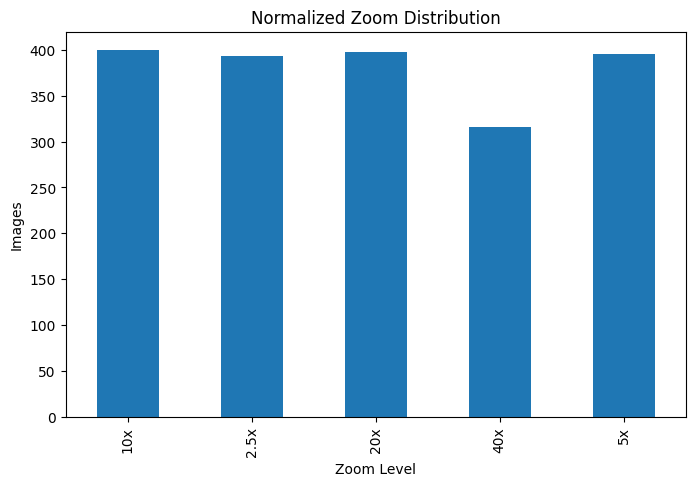

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
pathology_df["zoom_level"]\
    .value_counts()\
    .sort_index()\
    .plot(kind="bar")

plt.title("Normalized Zoom Distribution")
plt.xlabel("Zoom Level")
plt.ylabel("Images")
plt.show()

# 15. Check Patirnt Coverage Per Zoom : 

In [70]:
zoom_patient_stats = (pathology_df.groupby("zoom_level")["patient"].nunique())
print(zoom_patient_stats)

zoom_level
10x     198
2.5x    197
20x     198
40x     163
5x      198
Name: patient, dtype: int64


# 16. Create Multi-Scale Patient Mapping : 

In [71]:
patient_multiscale_map = {}

for patient, group in pathology_df.groupby("patient") :
    patient_multiscale_map[patient] = {
        "2.5x": [],
        "5x": [],
        "10x": [],
        "20x": [],
        "40x": []
    }

    for _, row in group.iterrows() :
        zoom = row["zoom_level"]
        if zoom in patient_multiscale_map[patient] :
            patient_multiscale_map[
                patient
            ][zoom].append(
                row["imageNames"]
            )

print("Patients : ", len(patient_multiscale_map))

Patients :  198


# 17. Inspect One Patient : 

In [72]:
sample_patient = list(patient_multiscale_map.keys())[0]
print("Patient : ", sample_patient)
for zoom, imgs in (patient_multiscale_map[sample_patient].items()) :
    print(zoom, len(imgs))

Patient :  patient1
2.5x 2
5x 3
10x 3
20x 3
40x 1


# 18. Total Images Per Scale : 

In [73]:
scale_counts = {}

for zoom in ["2.5x", "5x", "10x", "20x", "40x"]:
    scale_counts[zoom] = len(
        pathology_df[
            pathology_df["zoom_level"] == zoom
        ]
    )

pd.Series(scale_counts)

2.5x    393
5x      396
10x     400
20x     398
40x     316
dtype: int64

# 19. Patient Level Statistics : 

In [74]:
patient_image_counts = []
for patient in patient_multiscale_map :
    total_images = 0
    for zoom in patient_multiscale_map[patient] :
        total_images += len(
            patient_multiscale_map[
                patient
            ][zoom]
        )

    patient_image_counts.append(total_images)

pd.Series(patient_image_counts).describe()

count    198.000000
mean       9.611111
std        6.852713
min        3.000000
25%        5.000000
50%        8.500000
75%       10.000000
max       63.000000
dtype: float64

# 20. Save Multi Scale Mapping : 

In [75]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)
joblib.dump(patient_multiscale_map, "artifacts/patient_multiscale_map.pkl")

print("Saved Successfully")

Saved Successfully


# 21. Save Processed Dataframe : 

In [76]:
pathology_df.to_csv("artifacts/pathology_multiscale.csv", index=False)
print(pathology_df.shape)

(1903, 19)


# 22. Notebook Summary : 

In [77]:
print("="*60)
print("NOTEBOOK 4 COMPLETE")
print("="*60)

print("Patients : ", len(patient_multiscale_map))
print("Total Images : ", len(pathology_df))
print("Average Images Per Patient : ", round(np.mean(patient_image_counts), 2))

NOTEBOOK 4 COMPLETE
Patients :  198
Total Images :  1903
Average Images Per Patient :  9.61


# Notebook 5 : Multi-Scale DINOv2 Pathology Feature Extraction

# 1. Install Dependencies : 

In [101]:
!pip install transformers timm accelerate -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Import Libraries : 

In [78]:
import os
import joblib
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
from PIL import Image

from transformers import AutoImageProcessor
from transformers import AutoModel

# 3. Device : 

In [79]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

cuda


# 4. Load Mapping : 

In [80]:
patient_multiscale_map = joblib.load("artifacts/patient_multiscale_map.pkl")
print("Patients : ", len(patient_multiscale_map))

Patients :  198


# 5. Pathology Root : 

In [81]:
PATHO_ROOT = r"C:\Users\upadh\Downloads\histoImagesWithZoomingLabels"
ZOOM_FOLDERS = {
    "2.5x" : "2,5x",
    "5x" : "5x",
    "10x" : "10x",
    "20x" : "20x",
    "40x" : "40x"
}

# 6. Load DINOv2 : 

In [82]:
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-base")
dinov2.eval()
dinov2.to(device)

print("DINOv2 Loaded")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 Loaded


# 7. Image Loader : 

In [83]:
def load_image(img_path) :
    img = Image.open(img_path).convert("RGB")

    return img

# 8. DINOv2 Feature Extractor : 

In [84]:
@torch.no_grad()
def extract_dino_feature(img) :
    inputs = processor(images=img, return_tensors="pt")
    inputs = {k:v.to(device) for k,v in inputs.items()}
    outputs = dinov2(**inputs)
    feature = (outputs.last_hidden_state[:,0,:].squeeze().cpu().numpy())

    return feature

# 9. Simple Attention Pooling :  

In [85]:
def attention_pool(features) :
    features = np.array(features)
    weights = np.linalg.norm(features, axis=1)
    weights = (weights / weights.sum())
    pooled = np.sum(features * weights[:,None], axis=0)

    return pooled

# 10. Verify One Patient : 

In [86]:
sample_patient = list(
    patient_multiscale_map.keys()
)[0]

sample_patient

'patient1'

# 11. Extract Features For One Patient : 

In [87]:
all_feats = []

for zoom in patient_multiscale_map[sample_patient] :
    img_names = (patient_multiscale_map[sample_patient][zoom])
    for img_name in img_names :
        folder = ZOOM_FOLDERS[zoom]
        img_path = os.path.join(PATHO_ROOT, folder, img_name)

        if os.path.exists(img_path) :
            img = load_image(img_path)
            feat = extract_dino_feature(img)
            all_feats.append(feat)

print(len(all_feats))

12


# 12. Pool Sample Patient : 

In [88]:
patient_feature = attention_pool(all_feats)
print(patient_feature.shape)

(768,)


# 13. Full Dataset Feature Extraction : 

In [89]:
pathology_features = []
patient_ids = []

# 14. Main Loop : 

In [90]:
for patient in tqdm(patient_multiscale_map) :
    image_features = []

    for zoom in patient_multiscale_map[patient] :
        img_names = (patient_multiscale_map[patient][zoom])

        for img_name in img_names :
            folder = ZOOM_FOLDERS[zoom]
            img_path = os.path.join(PATHO_ROOT, folder, img_name)

            if not os.path.exists(img_path) :
                continue

            try :
                img = load_image(img_path)
                feat = (extract_dino_feature(img))
                image_features.append(feat)

            except :
                continue

    if len(image_features)==0 :
        continue

    pooled_feature = attention_pool(image_features)
    pathology_features.append(pooled_feature)
    patient_ids.append(patient)

100%|████████████████████████████████████████████████████████████████████████████████| 198/198 [07:48<00:00,  2.37s/it]


# 15. Convert To Array : 

In [91]:
pathology_features = np.array(pathology_features)
print(pathology_features.shape)

(198, 768)


# 16. Project To 512-D : 

In [92]:
import torch.nn as nn

projection = nn.Linear(768, 512)
with torch.no_grad() :
    pathology_features = (
        projection(
            torch.tensor(
                pathology_features,
                dtype=torch.float32
            )
        )
        .numpy()
    )

# 17. Verify : 

In [93]:
print(pathology_features.shape)

(198, 512)


# 18. Save Features : 

In [94]:
os.makedirs("features", exist_ok=True)
np.save("features/pathology_features.npy", pathology_features)
np.save("features/pathology_patient_ids.npy", np.array(patient_ids))

print("Saved")

Saved


# 19. Statistics : 

In [95]:
print(pathology_features.mean())
print(pathology_features.std())

-0.051553655
0.89466435


# 20. Notebook Summary : 

In [96]:
print("="*60)
print("NOTEBOOK 5 COMPLETE")
print("="*60)

print("Patients : ", len(patient_ids))
print("Feature Shape : ", pathology_features.shape)

NOTEBOOK 5 COMPLETE
Patients :  198
Feature Shape :  (198, 512)


# Notebook 6 : IHC Biomarker Embedding

# 1. Import Libraries ; 

In [97]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

# 2. Load Dataset : 

In [98]:
ihc_df = pd.read_csv("artifacts/ihc_clean.csv")

print(ihc_df.shape)
ihc_df.head()

(403, 18)


,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,1,colon,patient1,polyp1,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,20.0,47.0,2.0,15.0,2
1,1,colon,patient1,polyp2,M,53,descending,nonneoplastic,hyperplastic,40.0,negative,negative,negative,30.0,39.0,2.0,10.0,2
2,1,colon,patient1,polyp3,M,53,descending,nonneoplastic,hyperplastic,50.0,negative,negative,negative,50.0,50.0,3.0,20.0,2
3,2,colon,patient2,polyp1,M,49,ascending,nonneoplastic,hyperplastic,50.0,negative,negative,weak,40.0,63.0,3.0,5.0,2
4,2,colon,patient2,polyp2,M,49,descending,neoplastic,villous,60.0,negative,negative,weak,70.0,57.0,2.0,25.0,1


# 3. Check Unique Patients : 

In [99]:
print("Unique Patients : ", ihc_df["patient"].nunique())
print("Unique Polyps : ", ihc_df["polyp"].nunique())

Unique Patients :  201
Unique Polyps :  16


In [100]:
feature_cols = [
    "gender",
    "age",
    "location",
    "Ki-67(clone30-9)",
    "BRAF(cloneV600E)",
    "PD-L1epithelium(clone SP142)",
    "PD-L1lymphocyte(clone SP142)",
    "VEGF(clone SP125)",
    "CD34(cloneQBend/10)",
    "CD34(cloneQBend/10)skor",
    "p53(clonebp53-11)"
]

# 4. Seperate Numeric and Categorical Columns : 

In [101]:
numeric_cols = [
    "age",
    "Ki-67(clone30-9)",
    "VEGF(clone SP125)",
    "CD34(cloneQBend/10)",
    "CD34(cloneQBend/10)skor",
    "p53(clonebp53-11)"
]

categorical_cols = [
    "gender",
    "location",
    "BRAF(cloneV600E)",
    "PD-L1epithelium(clone SP142)",
    "PD-L1lymphocyte(clone SP142)"
]

# 5. Aggregate Per Patient : 

In [102]:
numeric_df = (ihc_df.groupby("patient")[numeric_cols].mean())

# 6. Aggregate Categoricals : 

In [103]:
categorical_df = (
    ihc_df
    .groupby("patient")[categorical_cols]
    .agg(
        lambda x : x.mode().iloc[0]
        if len(x.mode()) > 0
        else x.iloc[0]
    )
)

# 7. Merge Patient Records : 

In [104]:
patient_df = pd.concat(
    [numeric_df, categorical_df],
    axis=1
).reset_index()

# 8. Verify : 

In [105]:
print(patient_df.shape)
patient_df.head()

(201, 12)


,patient,age,Ki-67(clone30-9),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),gender,location,BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142)
0,patient1,53.0,46.666667,33.333333,45.333333,2.333333,15.00,M,descending,negative,negative,negative
1,patient10,83.0,70.000000,50.000000,58.000000,2.000000,50.00,M,rectum,negative,negative,weak
2,patient100,72.0,21.250000,65.000000,59.250000,2.000000,15.25,F,sigmoid,negative,negative,weak
3,patient101,63.0,25.000000,20.000000,30.000000,1.000000,10.00,F,sigmoid,negative,negative,weak
4,patient102,65.0,12.500000,10.000000,36.000000,1.500000,8.00,M,descending,negative,negative,weak


# 9. Missing Values : 

In [106]:
patient_df.isnull().sum()

patient                         0
age                             0
Ki-67(clone30-9)                6
VEGF(clone SP125)               5
CD34(cloneQBend/10)             5
CD34(cloneQBend/10)skor         5
p53(clonebp53-11)               5
gender                          0
location                        0
BRAF(cloneV600E)                5
PD-L1epithelium(clone SP142)    5
PD-L1lymphocyte(clone SP142)    5
dtype: int64

# 10. Fill Missing Values : 

In [107]:
for col in patient_df.columns :
    if col == "patient" :
        continue

    if patient_df[col].dtype == "object" :
        patient_df[col] = (
            patient_df[col]
            .fillna(
                patient_df[col].mode()[0]
            )
        )

    else :
        patient_df[col] = (
            patient_df[col]
            .fillna(
                patient_df[col].median()
            )
        )

# 11. Prepare Feature Matrix : 

In [108]:
X = patient_df.drop(columns=["patient"])
print(X.shape)

(201, 11)


# 12. Encode Categoricals : 

In [109]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.columns :
    if X[col].dtype == "object" :
        le = LabelEncoder()
        X[col] = le.fit_transform(
            X[col].astype(str)
        )
        encoders[col] = le

# 13. Standardize : 

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(201, 11)


# 14. Save Aggregated Patient Table : 

In [111]:
patient_df.to_csv("artifacts/ihc_patient_level.csv", index=False)
print("Saved")

Saved


In [112]:
patient_df.shape

(201, 12)

In [113]:
patient_df.head()

,patient,age,Ki-67(clone30-9),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),gender,location,BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142)
0,patient1,53.0,46.666667,33.333333,45.333333,2.333333,15.00,M,descending,negative,negative,negative
1,patient10,83.0,70.000000,50.000000,58.000000,2.000000,50.00,M,rectum,negative,negative,weak
2,patient100,72.0,21.250000,65.000000,59.250000,2.000000,15.25,F,sigmoid,negative,negative,weak
3,patient101,63.0,25.000000,20.000000,30.000000,1.000000,10.00,F,sigmoid,negative,negative,weak
4,patient102,65.0,12.500000,10.000000,36.000000,1.500000,8.00,M,descending,negative,negative,weak


# 15. Convert To Tensor : 

In [114]:
import torch

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
print(X_tensor.shape)

torch.Size([201, 11])


# 16. Biomarker Encoder : 

In [115]:
import torch.nn as nn

class BiomarkerEncoder(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 128)

        )

    def forward(self, x) :
        return self.encoder(x)

# 17. Initialize Model : 

In [116]:
encoder = BiomarkerEncoder()
encoder.eval()

BiomarkerEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
  )
)

# 18. Generate Biomarker Embedding : 

In [117]:
with torch.no_grad() :
    ihc_features = (encoder(X_tensor).cpu().numpy())

print(ihc_features.shape)

(201, 128)


# 19. Patient ID : 

In [118]:
patient_ids = (patient_df["patient"].astype(str).values)

print(len(patient_ids))

201


# 20. Save Features : 

In [119]:
import os
import numpy as np

os.makedirs("features", exist_ok=True)
np.save("features/ihc_features.npy", ihc_features)
np.save("features/ihc_patient_ids.npy", patient_ids)

print("Features Saved")

Features Saved


# 21. Verify Saved Features : 

In [120]:
loaded = np.load("features/ihc_features.npy")
print(loaded.shape)

(201, 128)


# 22. Statistics : 

In [121]:
print("Mean : ", ihc_features.mean())
print("Std  : ", ihc_features.std())
print("Min  : ", ihc_features.min())
print("Max  : ", ihc_features.max())

Mean :  0.0091400305
Std  :  0.25044093
Min  :  -1.4359758
Max  :  1.3788193


# 23. Notebook Summary : 

In [122]:
print("="*60)
print("NOTEBOOK 6 COMPLETE")
print("="*60)

print("Patients : ", len(patient_ids))
print("Feature Shape : ", ihc_features.shape)

NOTEBOOK 6 COMPLETE
Patients :  201
Feature Shape :  (201, 128)


In [123]:
print(video_features.shape)
print(pathology_features.shape)
print(ihc_features.shape)

(125, 512)
(198, 512)
(201, 128)


# Notebook 7 : Patient Alignment & Multimodal Dataset Creation

# 1. Import Libraries : 

In [124]:
import numpy as np
import pandas as pd

# 2. Load Patient IDs : 

In [125]:
video_patients = np.load("features/video_patient_ids.npy", allow_pickle=True)
pathology_patients = np.load("features/pathology_patient_ids.npy", allow_pickle=True)
ihc_patients = np.load("features/ihc_patient_ids.npy", allow_pickle=True)

print("Video : ", len(video_patients))
print("Pathology : ", len(pathology_patients))
print("IHC : ", len(ihc_patients))

Video :  125
Pathology :  198
IHC :  201


# 3. Convert To Sets : 

In [126]:
video_set = set(video_patients)
pathology_set = set(pathology_patients)
ihc_set = set(ihc_patients)

# 4. Find Common Patients : 

In [127]:
common_patients = sorted(
    list(video_set & pathology_set & ihc_set)
)

print("Common Patients : ", len(common_patients))

Common Patients :  122


In [128]:
video_only_missing = sorted(
    list(
        video_set -
        (pathology_set & ihc_set)
    )
)

print("Missing Common Patients : ", len(video_only_missing))
print(video_only_missing)

Missing Common Patients :  2
[np.str_('patient179'), np.str_('patient62')]


In [129]:
video_not_in_pathology = sorted(
    list(video_set - pathology_set)
)

video_not_in_ihc = sorted(
    list(video_set - ihc_set)
)

print("Missing in Pathology : ", len(video_not_in_pathology))
print(video_not_in_pathology)

print()

print("Missing in IHC : ", len(video_not_in_ihc))
print(video_not_in_ihc)

Missing in Pathology :  2
[np.str_('patient179'), np.str_('patient62')]

Missing in IHC :  0
[]


In [130]:
print("Video Patients : ", len(video_set))
print("Pathology Patients : ", len(pathology_set))
print("IHC Patients : ", len(ihc_set))

print("Common Patients : ",
      len(video_set & pathology_set & ihc_set))

Video Patients :  124
Pathology Patients :  198
IHC Patients :  201
Common Patients :  122


# 5. Load Features : 

In [131]:
video_features = np.load("features/video_features.npy")
pathology_features = np.load("features/pathology_features.npy")
ihc_features = np.load("features/ihc_features.npy")

print(video_features.shape)
print(pathology_features.shape)
print(ihc_features.shape)

(125, 512)
(198, 512)
(201, 128)


# 6. Create Patient To Index Mapping ; 

In [132]:
video_idx = {
    p:i
    for i,p in enumerate(video_patients)
}

pathology_idx = {
    p:i
    for i,p in enumerate(pathology_patients)
}

ihc_idx = {
    p:i
    for i,p in enumerate(ihc_patients)
}

# 7. Initialize Alligned List : 

In [133]:
aligned_video = []
aligned_pathology = []
aligned_ihc = []

# 8. Allign All Modalities : 

In [134]:
for patient in common_patients :
    aligned_video.append(
        video_features[
            video_idx[patient]
        ]
    )

    aligned_pathology.append(
        pathology_features[
            pathology_idx[patient]
        ]
    )

    aligned_ihc.append(
        ihc_features[
            ihc_idx[patient]
        ]
    )

# 9. Convert To NumPy Arrays : 

In [135]:
aligned_video = np.array(aligned_video)
aligned_pathology = np.array(aligned_pathology)
aligned_ihc = np.array(aligned_ihc)

print(aligned_video.shape)
print(aligned_pathology.shape)
print(aligned_ihc.shape)

(122, 512)
(122, 512)
(122, 128)


# 10. Load Metadata : 

In [136]:
video_df = pd.read_csv("artifacts/video_clean.csv")

video_df.head()

,ID,colon,patient,polyp,gender,age,location,type,subtype,Ki-67(clone30-9),BRAF(cloneV600E),PD-L1epithelium(clone SP142),PD-L1lymphocyte(clone SP142),VEGF(clone SP125),CD34(cloneQBend/10),CD34(cloneQBend/10)skor,p53(clonebp53-11),LabelID
0,58,colon,patient58,polyp1,M,42.0,rectum,nonneoplastic,hyperplastic,15.0,strong,weak,weak,50.0,1.0,32.0,5.0,2
1,85,colon,patient85,polyp1,M,83.0,sigmoid,nonneoplastic,hyperplastic,30.0,strong,negative,weak,40.0,1.0,22.0,15.0,2
2,92,colon,patient92,polyp1,M,61.0,rectum,nonneoplastic,hyperplastic,30.0,strong,negative,weak,10.0,2.0,70.0,10.0,2
3,109,colon,patient109,polyp1,M,45.0,sigmoid,nonneoplastic,hyperplastic,20.0,strong,negative,weak,40.0,3.0,76.0,10.0,2
4,108,colon,patient108,polyp1,F,50.0,sigmoid,neoplastic,tubular,40.0,negative,negative,strong,90.0,2.0,70.0,15.0,1


# 11. Create Patient -> Label Mapping : 

In [137]:
patient_label_map = (
    video_df
    .drop_duplicates("patient")
    .set_index("patient")
    ["LabelID"]
    .to_dict()
)

# 12. Generate Labels : 

In [138]:
labels = np.array([
    patient_label_map[p]
    for p in common_patients
])
print(labels.shape)

(122,)


# 13. Check Class Distribution : 

In [139]:
pd.Series(labels).value_counts()

1    72
2    45
0     5
Name: count, dtype: int64

In [140]:
video_df[["type", "LabelID"]].drop_duplicates().sort_values("LabelID")

,type,LabelID
10,carcinom,0
4,neoplastic,1
0,nonneoplastic,2


In [141]:
video_df.groupby("type")["patient"].nunique()

type
carcinom          6
neoplastic       76
nonneoplastic    51
Name: patient, dtype: int64

In [142]:
video_df[["type","LabelID"]].drop_duplicates()

,type,LabelID
0,nonneoplastic,2
4,neoplastic,1
10,carcinom,0


# 14. Save Features : 

In [143]:
np.save("features/aligned_video.npy", aligned_video)
np.save("features/aligned_pathology.npy", aligned_pathology)
np.save("features/aligned_ihc.npy", aligned_ihc)
np.save("features/aligned_labels.npy", labels)
np.save("features/common_patients.npy", np.array(common_patients))

print("Saved Successfully")

Saved Successfully


# 15. Verify : 

In [144]:
print(aligned_video.shape)
print(aligned_pathology.shape)
print(aligned_ihc.shape)
print(labels.shape)

(122, 512)
(122, 512)
(122, 128)
(122,)


# 16. Notebook Summmary : 

In [145]:
print("="*60)
print("NOTEBOOK 7 COMPLETE")
print("="*60)

print("Patients : ", len(common_patients))
print("Video : ", aligned_video.shape)
print("Pathology : ", aligned_pathology.shape)
print("IHC : ", aligned_ihc.shape)

print("\nClass Distribution")
print(pd.Series(labels).value_counts())

NOTEBOOK 7 COMPLETE
Patients :  122
Video :  (122, 512)
Pathology :  (122, 512)
IHC :  (122, 128)

Class Distribution
1    72
2    45
0     5
Name: count, dtype: int64


# Notebook 8 : Multimodal Fusion Model Training

# 1. Import Libraries : 

In [232]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 2. Reproducibility : 

In [233]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

Device : cuda


# 3. Load Alligned Features : 

In [234]:
video_features = np.load("features/aligned_video.npy")
pathology_features = np.load("features/aligned_pathology.npy")
ihc_features = np.load("features/aligned_ihc.npy")
labels = np.load("features/aligned_labels.npy")

print("Video :", video_features.shape)
print("Pathology :", pathology_features.shape)
print("IHC :", ihc_features.shape)
print("Labels :", labels.shape)

# Sanity checks
print("\nNaN Check")
print("Video :", np.isnan(video_features).sum())
print("Pathology :", np.isnan(pathology_features).sum())
print("IHC :", np.isnan(ihc_features).sum())

print("\nLabel Distribution")
print(pd.Series(labels).value_counts().sort_index())

Video : (122, 512)
Pathology : (122, 512)
IHC : (122, 128)
Labels : (122,)

NaN Check
Video : 0
Pathology : 0
IHC : 0

Label Distribution
0     5
1    72
2    45
Name: count, dtype: int64


# 4. Verify Class Distribution : 

Class Distribution
0     5
1    72
2    45
Name: count, dtype: int64


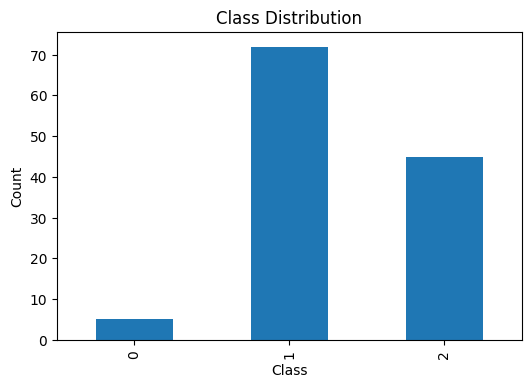

In [235]:
label_counts = pd.Series(labels).value_counts().sort_index()

print("Class Distribution")
print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 5. Dataset Class : 

In [236]:
class MultimodalDataset(Dataset) :
    def __init__(self, video, pathology, ihc, labels) :
        self.video = torch.tensor(video, dtype=torch.float32)
        self.pathology = torch.tensor(pathology, dtype=torch.float32)
        self.ihc = torch.tensor(ihc, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx) :

        return (self.video[idx], self.pathology[idx], self.ihc[idx], self.labels[idx])

# 6. Compute Class Weights : 

In [237]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)

# Smooth extreme imbalance
weights = np.sqrt(weights)

weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Class Weights :", weights)

Class Weights : tensor([2.8519, 0.7515, 0.9506], device='cuda:0')


# 7. Weighted Focal Loss : 

In [238]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.alpha
        )

        probs = torch.softmax(logits, dim=1)

        pt = probs.gather(
            1,
            targets.unsqueeze(1)
        ).squeeze(1)

        focal_weight = (1 - pt) ** self.gamma

        loss = focal_weight * ce_loss

        return loss.mean()

# 8. Biomarker Guided Gated Fusion Network : 

In [239]:
class MultimodalFusionNet(nn.Module):

    def __init__(self):
        super().__init__()

        # =========================
        # Video Branch
        # =========================
        self.video_proj = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # =========================
        # Pathology Branch
        # =========================
        self.path_proj = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # =========================
        # Biomarker Branch
        # =========================
        self.ihc_proj = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # =========================
        # Biomarker Guided Gates
        # =========================
        self.video_gate = nn.Sequential(
            nn.Linear(128, 256),
            nn.Sigmoid()
        )

        self.path_gate = nn.Sequential(
            nn.Linear(128, 256),
            nn.Sigmoid()
        )

        # =========================
        # Fusion Network
        # =========================
        self.fusion = nn.Sequential(
            nn.Linear(640, 256),  # 256 + 256 + 128
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Confidence Head
        self.confidence_head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        # Final Classifier
        self.classifier = nn.Linear(128, 3)

    def forward(self, video, pathology, ihc):

        video = self.video_proj(video)
        pathology = self.path_proj(pathology)
        ihc = self.ihc_proj(ihc)

        v_gate = self.video_gate(ihc)
        p_gate = self.path_gate(ihc)

        video = video * v_gate
        pathology = pathology * p_gate

        fused = torch.cat(
            [video, pathology, ihc],
            dim=1
        )

        embedding = self.fusion(fused)

        confidence = self.confidence_head(embedding)

        logits = self.classifier(embedding)

        return logits, confidence

# 9. ECE Function : 

In [240]:
import numpy as np

def expected_calibration_error(probs, labels, n_bins=10):

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    accuracies = (predictions == labels).astype(float)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (confidences >= bin_boundaries[i]) &
                (confidences <= bin_boundaries[i + 1])
            )
        else:
            mask = (
                (confidences >= bin_boundaries[i]) &
                (confidences < bin_boundaries[i + 1])
            )

        if np.any(mask):

            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()

            ece += (
                mask.mean() *
                abs(bin_acc - bin_conf)
            )

    return float(ece)

# 10. Stratified 5-Fold Setup : 

In [241]:
NUM_FOLDS = 5
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
print("Folds : ", NUM_FOLDS)

for fold, (_, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), 1) :
    fold_labels = labels[val_idx]
    print(f"Fold {fold} : ", pd.Series(fold_labels).value_counts().sort_index().to_dict())

Folds :  5
Fold 1 :  {0: 1, 1: 15, 2: 9}
Fold 2 :  {0: 1, 1: 15, 2: 9}
Fold 3 :  {0: 1, 1: 14, 2: 9}
Fold 4 :  {0: 1, 1: 14, 2: 9}
Fold 5 :  {0: 1, 1: 14, 2: 9}


# 11. Training Hyperparameters : 

In [242]:
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4
PATIENCE = 20
WEIGHT_DECAY = 5e-4

# 12. Containers For Result : 

In [243]:
fold_results = []
all_true = []
all_pred = []
all_probs = []
history_per_fold = []
train_acc_per_fold = []
val_acc_per_fold = []

# 13. Start Cross Validation Loop : 

In [244]:
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score

In [246]:
for fold, (train_idx, val_idx) in enumerate(
    skf.split(video_features, labels)
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold+1}/{NUM_FOLDS}")
    print("=" * 60)

    # =====================================================
    # SPLIT DATA
    # =====================================================
    X_video_train = video_features[train_idx]
    X_video_val = video_features[val_idx]

    X_path_train = pathology_features[train_idx]
    X_path_val = pathology_features[val_idx]

    X_ihc_train = ihc_features[train_idx]
    X_ihc_val = ihc_features[val_idx]

    y_train = labels[train_idx]
    y_val = labels[val_idx]

    # =====================================================
    # DATASETS
    # =====================================================
    train_dataset = MultimodalDataset(
        X_video_train,
        X_path_train,
        X_ihc_train,
        y_train
    )

    val_dataset = MultimodalDataset(
        X_video_val,
        X_path_val,
        X_ihc_val,
        y_val
    )

    # =====================================================
    # WEIGHTED SAMPLER
    # =====================================================
    class_counts = np.bincount(y_train)

    sample_weights = np.array(
        [1.0 / class_counts[label] for label in y_train]
    )

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # =====================================================
    # MODEL
    # =====================================================
    model = MultimodalFusionNet().to(DEVICE)

    criterion = FocalLoss(
        alpha=weights,
        gamma=2.0
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    best_f1 = 0
    patience_counter = 0

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_model_path = f"best_fold_{fold}.pth"

    # =====================================================
    # TRAINING LOOP
    # =====================================================
    for epoch in range(EPOCHS):

        # =================================================
        # TRAIN
        # =================================================
        model.train()

        running_train_loss = 0

        train_preds = []
        train_targets = []

        for (
            video_batch,
            path_batch,
            ihc_batch,
            label_batch
        ) in train_loader:

            video_batch = video_batch.to(DEVICE)
            path_batch = path_batch.to(DEVICE)
            ihc_batch = ihc_batch.to(DEVICE)
            label_batch = label_batch.to(DEVICE)

            optimizer.zero_grad()

            logits, confidence = model(
                video_batch,
                path_batch,
                ihc_batch
            )

            loss = criterion(
                logits,
                label_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            running_train_loss += loss.item()

            preds = torch.argmax(
                logits,
                dim=1
            )

            train_preds.extend(
                preds.detach().cpu().numpy()
            )

            train_targets.extend(
                label_batch.cpu().numpy()
            )

        avg_train_loss = (
            running_train_loss /
            len(train_loader)
        )

        train_losses.append(
            avg_train_loss
        )

        train_acc = accuracy_score(
            train_targets,
            train_preds
        )

        train_accs.append(
            train_acc
        )

        # =================================================
        # VALIDATION
        # =================================================
        model.eval()

        running_val_loss = 0

        val_preds = []
        val_targets = []

        val_probabilities = []

        with torch.no_grad():

            for (
                video_batch,
                path_batch,
                ihc_batch,
                label_batch
            ) in val_loader:

                video_batch = video_batch.to(DEVICE)
                path_batch = path_batch.to(DEVICE)
                ihc_batch = ihc_batch.to(DEVICE)
                label_batch = label_batch.to(DEVICE)

                logits, confidence = model(
                    video_batch,
                    path_batch,
                    ihc_batch
                )

                loss = criterion(
                    logits,
                    label_batch
                )

                running_val_loss += loss.item()

                probs = torch.softmax(
                    logits,
                    dim=1
                )

                preds = torch.argmax(
                    probs,
                    dim=1
                )

                val_preds.extend(
                    preds.cpu().numpy()
                )

                val_targets.extend(
                    label_batch.cpu().numpy()
                )

                val_probabilities.extend(
                    probs.cpu().numpy()
                )

        avg_val_loss = (
            running_val_loss /
            len(val_loader)
        )

        val_losses.append(
            avg_val_loss
        )

        val_acc = accuracy_score(
            val_targets,
            val_preds
        )

        val_accs.append(
            val_acc
        )

        macro_f1 = f1_score(
            val_targets,
            val_preds,
            average="macro",
            zero_division=0
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Acc: {val_acc:.4f} "
            f"Macro F1: {macro_f1:.4f} "
            f"LR: {current_lr:.6f}"
        )

        # =============================================
        # SAVE BEST MODEL
        # =============================================
        if macro_f1 > best_f1:

            best_f1 = macro_f1
            patience_counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

        else:

            patience_counter += 1

        # =============================================
        # EARLY STOPPING
        # =============================================
        if patience_counter >= PATIENCE:

            print(
                f"Early stopping at epoch {epoch+1}"
            )
            break

    history_per_fold.append(
        {
            "train_loss": train_losses,
            "val_loss": val_losses,
            "train_acc": train_accs,
            "val_acc": val_accs
        }
    )

    train_acc_per_fold.append(
        max(train_accs)
    )

    val_acc_per_fold.append(
        max(val_accs)
    )

    fold_results.append(
        best_f1
    )

    print(
        f"Best Macro F1 : {best_f1:.4f}"
    )


FOLD 1/5
Epoch [1/100] Train Loss: 0.6914 Val Loss: 0.3947 Train Acc: 0.4688 Val Acc: 0.6000 Macro F1: 0.2500 LR: 0.000100
Epoch [2/100] Train Loss: 0.7205 Val Loss: 0.3661 Train Acc: 0.3854 Val Acc: 0.6000 Macro F1: 0.2500 LR: 0.000100
Epoch [3/100] Train Loss: 0.5887 Val Loss: 0.3277 Train Acc: 0.6042 Val Acc: 0.6400 Macro F1: 0.3634 LR: 0.000100
Epoch [4/100] Train Loss: 0.6400 Val Loss: 0.2696 Train Acc: 0.5938 Val Acc: 0.6800 Macro F1: 0.4131 LR: 0.000100
Epoch [5/100] Train Loss: 0.4006 Val Loss: 0.2353 Train Acc: 0.6354 Val Acc: 0.8000 Macro F1: 0.8482 LR: 0.000099
Epoch [6/100] Train Loss: 0.3682 Val Loss: 0.1956 Train Acc: 0.7188 Val Acc: 0.8000 Macro F1: 0.5388 LR: 0.000099
Epoch [7/100] Train Loss: 0.2617 Val Loss: 0.1939 Train Acc: 0.7812 Val Acc: 0.7600 Macro F1: 0.5123 LR: 0.000099
Epoch [8/100] Train Loss: 0.2199 Val Loss: 0.1855 Train Acc: 0.7812 Val Acc: 0.8000 Macro F1: 0.5425 LR: 0.000098
Epoch [9/100] Train Loss: 0.2582 Val Loss: 0.1748 Train Acc: 0.6875 Val Acc: 0

# 14. Evaluation Loop : 

In [247]:
all_true = []
all_pred = []
all_prob = []

In [248]:
for fold, (train_idx, val_idx) in enumerate(skf.split(video_features, labels)) :
    model = MultimodalFusionNet().to(DEVICE)
    model.load_state_dict(torch.load(f"best_fold_{fold}.pth"))
    model.eval()
    X_video_val = video_features[val_idx]
    X_path_val = pathology_features[val_idx]
    X_ihc_val = ihc_features[val_idx]
    y_val = labels[val_idx]
    dataset = MultimodalDataset(X_video_val, X_path_val, X_ihc_val, y_val)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    with torch.no_grad():
        for (video_batch, path_batch, ihc_batch, label_batch) in loader :
            video_batch = video_batch.to(DEVICE)
            path_batch = path_batch.to(DEVICE)
            ihc_batch = ihc_batch.to(DEVICE)
            logits, _ = model(video_batch, path_batch, ihc_batch)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_true.extend(label_batch.numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

# 15. Convert To Array : 

In [249]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_prob = np.array(all_prob)

print(all_true.shape)
print(all_pred.shape)
print(all_prob.shape)

(122,)
(122,)
(122, 3)


# 16. Train Matrics Function : 

In [250]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

def calculate_metrics(y_true, y_pred) :
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return acc, prec, rec, f1

# 17. Evaluate Best Model On Train & Validation : 

In [251]:
train_dataset = MultimodalDataset(
    X_video_train,
    X_path_train,
    X_ihc_train,
    y_train
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

# 18. Train Predictions : 

In [252]:
train_true = []
train_pred = []

with torch.no_grad() :
    for video_batch, path_batch, ihc_batch, label_batch in train_loader:
        video_batch = video_batch.to(DEVICE)
        path_batch = path_batch.to(DEVICE)
        ihc_batch = ihc_batch.to(DEVICE)
        logits, _ = model(video_batch, path_batch, ihc_batch)
        preds = torch.argmax(logits, dim=1)
        train_true.extend(label_batch.numpy())
        train_pred.extend(preds.cpu().numpy())

# 19. Validation Predictions : 

In [253]:
val_true = []
val_pred = []

with torch.no_grad() :
    for video_batch, path_batch, ihc_batch, label_batch in loader :
        video_batch = video_batch.to(DEVICE)
        path_batch = path_batch.to(DEVICE)
        ihc_batch = ihc_batch.to(DEVICE)
        logits, _ = model(video_batch, path_batch, ihc_batch)
        preds = torch.argmax(logits, dim=1)
        val_true.extend(label_batch.numpy())
        val_pred.extend(preds.cpu().numpy())

# 20. Train Metrics : 

In [254]:
train_acc, train_prec, train_rec, train_f1 = calculate_metrics(train_true, train_pred)

print("\nTRAIN METRICS")
print("-"*40)

print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1 Score  : {train_f1:.4f}")


TRAIN METRICS
----------------------------------------
Accuracy  : 0.9694
Precision : 0.9744
Recall    : 0.9828
F1 Score  : 0.9778


# 21. Test Metrics : 

In [255]:
val_acc, val_prec, val_rec, val_f1 = calculate_metrics(val_true, val_pred)

print("\nVALIDATION METRICS")
print("-"*40)

print(f"Accuracy  : {val_acc:.4f}")
print(f"Precision : {val_prec:.4f}")
print(f"Recall    : {val_rec:.4f}")
print(f"F1 Score  : {val_f1:.4f}")


VALIDATION METRICS
----------------------------------------
Accuracy  : 0.9167
Precision : 0.9392
Recall    : 0.9392
F1 Score  : 0.9392


# 22. Store Metrics Accross Fold : 

In [256]:
train_metrics_all = []
val_metrics_all = []

In [257]:
train_metrics_all.append(
    [train_acc, train_prec, train_rec, train_f1]
)

val_metrics_all.append(
    [val_acc, val_prec, val_rec, val_f1]
)

# 23. Final Avg Metrics : 

In [258]:
train_metrics_all = np.array(train_metrics_all)
val_metrics_all = np.array(val_metrics_all)

print("="*60)
print("AVERAGE TRAIN METRICS")
print("="*60)

print("Accuracy  :", train_metrics_all[:,0].mean())
print("Precision :", train_metrics_all[:,1].mean())
print("Recall    :", train_metrics_all[:,2].mean())
print("F1 Score  :", train_metrics_all[:,3].mean())

print()

print("="*60)
print("AVERAGE VALIDATION METRICS")
print("="*60)

print("Accuracy  :", val_metrics_all[:,0].mean())
print("Precision :", val_metrics_all[:,1].mean())
print("Recall    :", val_metrics_all[:,2].mean())
print("F1 Score  :", val_metrics_all[:,3].mean())

AVERAGE TRAIN METRICS
Accuracy  : 0.9693877551020408
Precision : 0.9743589743589745
Recall    : 0.9827586206896551
F1 Score  : 0.9778171091445428

AVERAGE VALIDATION METRICS
Accuracy  : 0.9166666666666666
Precision : 0.9391534391534391
Recall    : 0.9391534391534391
F1 Score  : 0.9391534391534391


# 24. Classification Mterics : 

In [259]:
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        all_true,
        all_pred,
        target_names=[
            "carcinom",
            "neoplastic",
            "nonneoplastic"
        ],
        digits=4
    )
)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

     carcinom     0.7500    0.6000    0.6667         5
   neoplastic     0.8873    0.8750    0.8811        72
nonneoplastic     0.7872    0.8222    0.8043        45

     accuracy                         0.8443       122
    macro avg     0.8082    0.7657    0.7840       122
 weighted avg     0.8448    0.8443    0.8440       122



# 25. Confusion Matrix : 

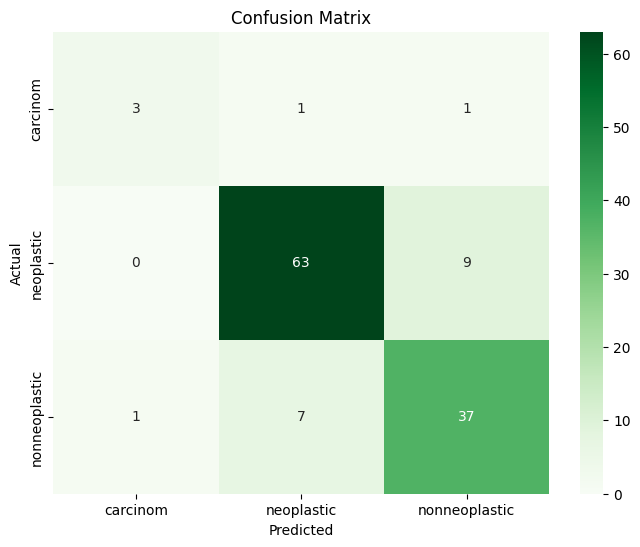

In [284]:
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "carcinom",
        "neoplastic",
        "nonneoplastic"
    ],
    yticklabels=[
        "carcinom",
        "neoplastic",
        "nonneoplastic"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 26. Sensitivity & Specificity : 

In [261]:
def sensitivity_specificity(cm) :
    sensitivity = []
    specificity = []

    for i in range(cm.shape[0]) :
        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - TP - FN - FP
        sensitivity.append(TP/(TP+FN+1e-8))
        specificity.append(TN/(TN+FP+1e-8))

    return sensitivity, specificity

In [262]:
sens, spec = sensitivity_specificity(cm)

classes = [
    "carcinom",
    "neoplastic",
    "nonneoplastic"
]

print("="*60)
print("SENSITIVITY & SPECIFICITY")
print("="*60)

for i,cls in enumerate(classes) :
    print(f"\n{cls}")
    print(f"Sensitivity : {sens[i]:.4f}")
    print(f"Specificity : {spec[i]:.4f}")

SENSITIVITY & SPECIFICITY

carcinom
Sensitivity : 0.6000
Specificity : 0.9915

neoplastic
Sensitivity : 0.8750
Specificity : 0.8400

nonneoplastic
Sensitivity : 0.8222
Specificity : 0.8701


# 27. ROC-AUC Score : 

In [263]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    all_true,
    classes=[0,1,2]
)

roc_auc = roc_auc_score(
    y_true_bin,
    all_prob,
    average="macro",
    multi_class="ovr"
)

print("="*60)
print("ROC-AUC")
print("="*60)

print(f"Macro ROC-AUC : {roc_auc:.4f}")

ROC-AUC
Macro ROC-AUC : 0.8767


# 28. ROC Curve : 

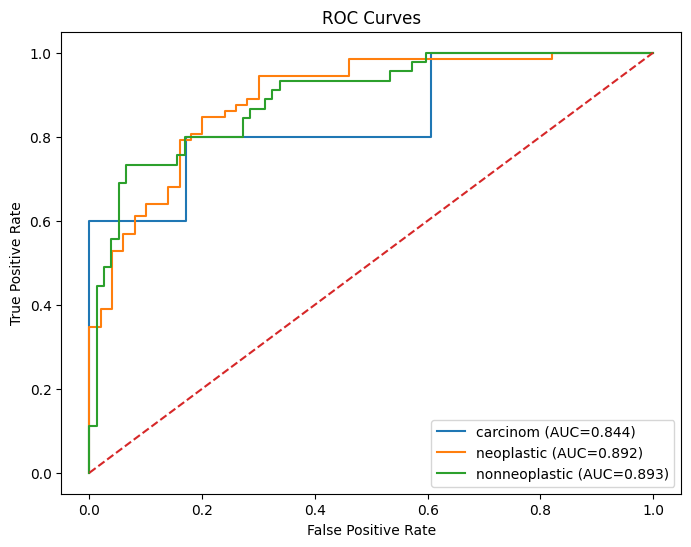

In [264]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

class_names = [
    "carcinom",
    "neoplastic",
    "nonneoplastic"
]

for i in range(3) :
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], all_prob[:,i])
    roc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_score:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# 29. Multi-Class Brier Score : 

In [265]:
brier_score = np.mean(
    np.sum(
        (
            all_prob
            -
            y_true_bin
        )**2,
        axis=1
    )
)

print("="*60)
print("BRIER SCORE")
print("="*60)

print(f"Brier Score : {brier_score:.4f}")

BRIER SCORE
Brier Score : 0.3672


# 30. Expected Calibration Error : 

In [266]:
ece = expected_calibration_error(all_prob, all_true, n_bins=10)

print("="*60)
print("EXPECTED CALIBRATION ERROR")
print("="*60)

print(f"ECE : {ece:.4f}")

EXPECTED CALIBRATION ERROR
ECE : 0.2687


# 31. Loss Curve : 

In [267]:
min_epochs = min(
    len(h["train_loss"])
    for h in history_per_fold
)

train_mean = np.mean(
    [
        h["train_loss"][:min_epochs]
        for h in history_per_fold
    ],
    axis=0
)

val_mean = np.mean(
    [
        h["val_loss"][:min_epochs]
        for h in history_per_fold
    ],
    axis=0
)

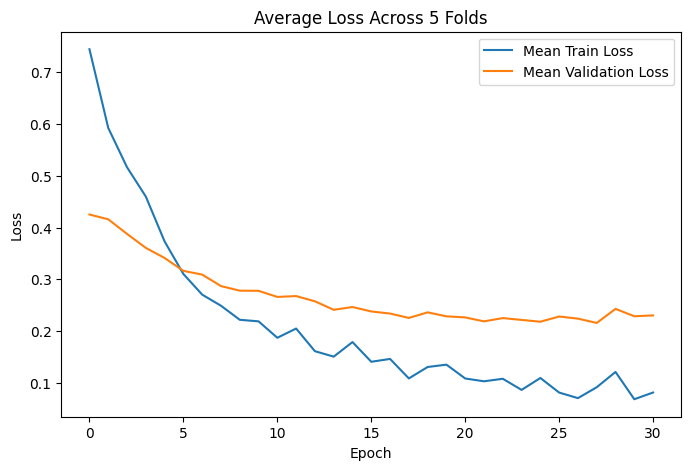

In [268]:
plt.figure(figsize=(8,5))

plt.plot(
    train_mean,
    label="Mean Train Loss"
)

plt.plot(
    val_mean,
    label="Mean Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Average Loss Across 5 Folds"
)

plt.legend()
plt.show()

# 32. Final Summary Table : 

In [270]:
summary = pd.DataFrame({
    "Metric":[
        "Macro ROC-AUC",
        "Brier Score",
        "ECE"

    ],

    "Value":[
        roc_auc,
        brier_score,
        ece
    ]
})

summary

,Metric,Value
0,Macro ROC-AUC,0.876721
1,Brier Score,0.367172
2,ECE,0.268685
